# Proyecto Final Big Data Tools

## Análisis de casos RU: Reclutamiento y Utilización de Niños, Niñas y Adolescentes

Este notebook contiene una versión **simple, completa y ejecutable** del proyecto:

1. carga de datos;
2. limpieza básica;
3. análisis exploratorio;
4. visualizaciones;
5. creación de variable objetivo;
6. modelo predictivo inicial;
7. exportación de tablas y figuras para el reporte.

> Ejecutar con el kernel: **Python (proyectofinalbdtools)**.

## 1. Librerías y rutas del proyecto

Esta celda prepara las rutas del repositorio. Funciona tanto si el notebook se ejecuta desde la carpeta `notebooks/` como desde la raíz del proyecto.

In [16]:
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

# Configuración visual básica
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Detectar raíz del proyecto
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
REPORTS_FIGURES = REPORTS / "figures"
REPORTS_TABLES = REPORTS / "tables"

for folder in [DATA_RAW, DATA_PROCESSED, REPORTS_FIGURES, REPORTS_TABLES]:
    folder.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_ROOT)
print("Carpeta de datos crudos:", DATA_RAW)
print("Carpeta de figuras:", REPORTS_FIGURES)
print("Carpeta de tablas:", REPORTS_TABLES)

Raíz del proyecto: c:\Users\HOME\Documents\Enfasis Big Data Tools\Proyecto\proyectofinalbdtools_starter
Carpeta de datos crudos: c:\Users\HOME\Documents\Enfasis Big Data Tools\Proyecto\proyectofinalbdtools_starter\data\raw
Carpeta de figuras: c:\Users\HOME\Documents\Enfasis Big Data Tools\Proyecto\proyectofinalbdtools_starter\reports\figures
Carpeta de tablas: c:\Users\HOME\Documents\Enfasis Big Data Tools\Proyecto\proyectofinalbdtools_starter\reports\tables


## 2. Carga del archivo CSV

El archivo debe estar en `data/raw/`. El notebook toma automáticamente el primer `.csv` que encuentre en esa carpeta.

In [17]:
csv_files = sorted(DATA_RAW.glob("*.csv"))

# Respaldo: si el CSV quedó por accidente en la raíz del proyecto, también lo busca ahí.
if len(csv_files) == 0:
    csv_files = sorted(PROJECT_ROOT.glob("*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No se encontró ningún archivo CSV. Copia la base en data/raw/ y vuelve a ejecutar."
    )

csv_path = csv_files[0]
print("Archivo seleccionado:", csv_path.name)

# Se lee todo como texto para evitar que años como 2.004 se interpreten mal.
raw = pd.read_csv(csv_path, encoding="utf-8", sep=None, engine="python", dtype=str)

print("Dimensiones iniciales:", raw.shape)
raw.head()

Archivo seleccionado: Sistema_de_Información_de_Eventos_de_Violencia_del_Conflicto_Armado_SIEVCAC_-_Casos_RU_Reclutamiento_y_Utilización_de_Niños,_Niñas_y_Adolescentes_20260503.csv
Dimensiones iniciales: (17201, 27)


,ID Caso,ID Caso Relacionado,Año,Mes,Día,Código DANE de Municipio,Municipio,Departamento,Región,Modalidad,...,Extorsión,Lesionados Civiles,Pillaje,Tortura,Violencia Basada en Género,Otro Hecho Simultáneo,Total de Víctimas del Caso,Forma de Vinculación,Tipo de Vinculación,latitud-longitud
0,152.888,NaN,2.004,4,0,05585,PUERTO NARE,ANTIOQUIA,MAGDALENA MEDIO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,SIN INFORMACIÓN,RECLUTAMIENTO,POINT (-74.5716887665 6.2194810893)
1,207.556,NaN,2.001,4,25,05756,SONSON,ANTIOQUIA,ORIENTE ANTIOQUEÑO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-74.82807326 5.837681474)
2,209.268,NaN,0,0,0,05234,DABEIBA,ANTIOQUIA,OCCIDENTE ANTIOQUEÑO,DESCONOCIDA,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-76.31426328 6.992243782)
3,225.057,NaN,1.988,0,0,68689,SAN VICENTE DE CHUCURI,SANTANDER,MAGDALENA MEDIO,COACCIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-73.53900334 6.894292346)
4,228.661,NaN,1.998,2,15,66456,MISTRATO,RISARALDA,EJE CAFETERO,PERSUASIÓN,...,0,0,0,0,NaN,OCULTAMIENTO DE CADÁVER,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-75.90432634 5.416268487)


## 3. Calidad inicial de datos

Resumen inicial de columnas, tipos de dato y valores faltantes.

In [18]:
calidad_inicial = pd.DataFrame({
    "columna_original": raw.columns,
    "tipo_dato": [str(raw[col].dtype) for col in raw.columns],
    "nulos": [raw[col].isna().sum() for col in raw.columns],
    "porcentaje_nulos": [round(raw[col].isna().mean() * 100, 2) for col in raw.columns],
    "valores_unicos": [raw[col].nunique(dropna=True) for col in raw.columns]
})

calidad_inicial.to_csv(REPORTS_TABLES / "calidad_datos_inicial.csv", index=False, encoding="utf-8-sig")
calidad_inicial

,columna_original,tipo_dato,nulos,porcentaje_nulos,valores_unicos
0,ID Caso,str,0,0.00,17201
1,ID Caso Relacionado,str,16831,97.85,360
2,Año,str,0,0.00,51
3,Mes,str,0,0.00,13
4,Día,str,0,0.00,32
5,Código DANE de Municipio,str,0,0.00,833
6,Municipio,str,0,0.00,765
7,Departamento,str,0,0.00,35
8,Región,str,27,0.16,76
9,Modalidad,str,0,0.00,5


## 4. Limpieza y normalización

Se normalizan nombres de columnas, fechas, víctimas, hechos simultáneos y coordenadas geográficas.

In [19]:
def normalizar_nombre_columna(nombre: str) -> str:
    """Convierte nombres de columnas a snake_case sin tildes."""
    nombre = str(nombre).strip().lower()
    nombre = unicodedata.normalize("NFKD", nombre).encode("ascii", "ignore").decode("utf-8")
    nombre = re.sub(r"[^a-z0-9]+", "_", nombre)
    nombre = re.sub(r"_+", "_", nombre).strip("_")
    return nombre


def limpiar_texto_serie(serie: pd.Series) -> pd.Series:
    """Limpia columnas de texto manteniendo valores faltantes."""
    return (
        serie.astype("string")
        .str.strip()
        .str.upper()
        .replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})
    )


def normalizar_anio(valor):
    """Convierte años tipo '2.004' a 2004 y '0.000' a NA."""
    if pd.isna(valor):
        return pd.NA
    texto = str(valor).strip()
    if texto == "":
        return pd.NA
    digitos = re.sub(r"\D", "", texto)
    if digitos == "":
        return pd.NA
    anio = int(digitos)
    if anio == 0:
        return pd.NA
    return anio


def a_numero(valor):
    """Convierte texto numérico a número; si falla devuelve NaN."""
    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip().replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return np.nan


def extraer_coordenadas(wkt):
    """Extrae longitud y latitud de textos tipo POINT (-74.57 6.21)."""
    if pd.isna(wkt):
        return pd.Series({"longitud": np.nan, "latitud": np.nan})
    texto = str(wkt)
    match = re.search(r"POINT\s*\(\s*([-\d\.]+)\s+([-\d\.]+)\s*\)", texto)
    if not match:
        return pd.Series({"longitud": np.nan, "latitud": np.nan})
    return pd.Series({"longitud": float(match.group(1)), "latitud": float(match.group(2))})

# Copia de trabajo

df = raw.copy()
df.columns = [normalizar_nombre_columna(col) for col in df.columns]

# Limpieza de columnas textuales principales
columnas_texto = [
    "municipio", "departamento", "region", "modalidad",
    "presunto_responsable", "descripcion_presunto_responsable",
    "forma_de_vinculacion", "tipo_de_vinculacion", "otro_hecho_simultaneo",
    "violencia_basada_en_genero"
]

for col in columnas_texto:
    if col in df.columns:
        df[col] = limpiar_texto_serie(df[col])

# Variables temporales
if "ano" in df.columns:
    df["anio"] = df["ano"].apply(normalizar_anio).astype("Int64")
else:
    raise KeyError("No se encontró la columna de año. Revisa el nombre de la columna en el CSV.")

for col in ["mes", "dia"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# Variable de víctimas
if "total_de_victimas_del_caso" not in df.columns:
    raise KeyError("No se encontró la columna total_de_victimas_del_caso.")

df["total_de_victimas_del_caso"] = pd.to_numeric(
    df["total_de_victimas_del_caso"], errors="coerce"
).fillna(0).astype(int)

# Hechos simultáneos codificados como 0/1
columnas_hechos = [
    "abandono_o_despojo_forzado_de_tierras",
    "amenaza_o_intimidacion",
    "ataque_contra_mision_medica",
    "confinamiento_o_restriccion_a_la_movilidad",
    "desplazamiento_forzado",
    "extorsion",
    "lesionados_civiles",
    "pillaje",
    "tortura"
]

for col in columnas_hechos:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# Variables derivadas de hechos simultáneos
columnas_hechos_presentes = [col for col in columnas_hechos if col in df.columns]
df["numero_hechos_simultaneos_binarios"] = df[columnas_hechos_presentes].sum(axis=1)
df["tiene_hecho_simultaneo"] = (df["numero_hechos_simultaneos_binarios"] > 0).astype(int)

if "otro_hecho_simultaneo" in df.columns:
    df["tiene_otro_hecho_simultaneo"] = df["otro_hecho_simultaneo"].notna().astype(int)
else:
    df["tiene_otro_hecho_simultaneo"] = 0

if "violencia_basada_en_genero" in df.columns:
    df["tiene_violencia_basada_genero"] = df["violencia_basada_en_genero"].notna().astype(int)
else:
    df["tiene_violencia_basada_genero"] = 0

# Coordenadas
if "latitud_longitud" in df.columns:
    coordenadas = df["latitud_longitud"].apply(extraer_coordenadas)
    df = pd.concat([df, coordenadas], axis=1)
else:
    df["latitud"] = np.nan
    df["longitud"] = np.nan

# Variable objetivo para el modelo
# Caso de alto impacto: más de una víctima registrada en el caso.
df["alto_impacto"] = (df["total_de_victimas_del_caso"] > 1).astype(int)

print("Dimensiones después de limpieza:", df.shape)
df.head()

Dimensiones después de limpieza: (17201, 35)


,id_caso,id_caso_relacionado,ano,mes,dia,codigo_dane_de_municipio,municipio,departamento,region,modalidad,...,tipo_de_vinculacion,latitud_longitud,anio,numero_hechos_simultaneos_binarios,tiene_hecho_simultaneo,tiene_otro_hecho_simultaneo,tiene_violencia_basada_genero,longitud,latitud,alto_impacto
0,152.888,NaN,2.004,4,0,05585,PUERTO NARE,ANTIOQUIA,MAGDALENA MEDIO,PERSUASIÓN,...,RECLUTAMIENTO,POINT (-74.5716887665 6.2194810893),2004,1,1,0,0,-74.571689,6.219481,0
1,207.556,NaN,2.001,4,25,05756,SONSON,ANTIOQUIA,ORIENTE ANTIOQUEÑO,PERSUASIÓN,...,RECLUTAMIENTO,POINT (-74.82807326 5.837681474),2001,1,1,0,0,-74.828073,5.837681,0
2,209.268,NaN,0,0,0,05234,DABEIBA,ANTIOQUIA,OCCIDENTE ANTIOQUEÑO,DESCONOCIDA,...,RECLUTAMIENTO,POINT (-76.31426328 6.992243782),<NA>,0,0,0,0,-76.314263,6.992244,0
3,225.057,NaN,1.988,0,0,68689,SAN VICENTE DE CHUCURI,SANTANDER,MAGDALENA MEDIO,COACCIÓN,...,RECLUTAMIENTO,POINT (-73.53900334 6.894292346),1988,0,0,0,0,-73.539003,6.894292,0
4,228.661,NaN,1.998,2,15,66456,MISTRATO,RISARALDA,EJE CAFETERO,PERSUASIÓN,...,RECLUTAMIENTO,POINT (-75.90432634 5.416268487),1998,0,0,1,0,-75.904326,5.416268,0


## 5. Resumen general del conjunto de datos

Esta tabla resume el tamaño de la base, cobertura temporal y distribución de la variable objetivo.

In [20]:
resumen_general = pd.DataFrame({
    "indicador": [
        "registros", "columnas", "anio_minimo", "anio_maximo",
        "departamentos", "municipios", "victimas_totales",
        "casos_alto_impacto", "porcentaje_alto_impacto"
    ],
    "valor": [
        len(df),
        df.shape[1],
        int(df["anio"].min()) if df["anio"].notna().any() else "Sin dato",
        int(df["anio"].max()) if df["anio"].notna().any() else "Sin dato",
        df["departamento"].nunique(dropna=True) if "departamento" in df.columns else "Sin dato",
        df["municipio"].nunique(dropna=True) if "municipio" in df.columns else "Sin dato",
        int(df["total_de_victimas_del_caso"].sum()),
        int(df["alto_impacto"].sum()),
        round(df["alto_impacto"].mean() * 100, 2)
    ]
})

resumen_general.to_csv(REPORTS_TABLES / "resumen_general.csv", index=False, encoding="utf-8-sig")
resumen_general

,indicador,valor
0,registros,17201.00
1,columnas,35.00
2,anio_minimo,1962.00
3,anio_maximo,2024.00
4,departamentos,35.00
5,municipios,765.00
6,victimas_totales,18182.00
7,casos_alto_impacto,394.00
8,porcentaje_alto_impacto,2.29


## 6. Análisis exploratorio descriptivo

Se generan tablas agregadas para analizar patrones por departamento, año, modalidad y presunto responsable.

In [21]:
# Casos por departamento
if "departamento" in df.columns:
    tabla_departamento = (
        df.groupby("departamento", dropna=False)
        .agg(
            casos=("departamento", "size"),
            victimas=("total_de_victimas_del_caso", "sum"),
            casos_alto_impacto=("alto_impacto", "sum")
        )
        .reset_index()
        .sort_values("casos", ascending=False)
    )
    tabla_departamento.to_csv(REPORTS_TABLES / "tabla_departamento.csv", index=False, encoding="utf-8-sig")
    display(tabla_departamento.head(15))

# Casos por año
if "anio" in df.columns:
    tabla_anio = (
        df.dropna(subset=["anio"])
        .groupby("anio")
        .agg(
            casos=("anio", "size"),
            victimas=("total_de_victimas_del_caso", "sum"),
            casos_alto_impacto=("alto_impacto", "sum")
        )
        .reset_index()
        .sort_values("anio")
    )
    tabla_anio.to_csv(REPORTS_TABLES / "tabla_anio.csv", index=False, encoding="utf-8-sig")
    display(tabla_anio.head())

,departamento,casos,victimas,casos_alto_impacto
1,ANTIOQUIA,2749,2879,46
29,SIN INFORMACION,2413,2593,80
22,META,1513,1586,32
9,CAQUETA,1263,1287,14
11,CAUCA,776,817,28
31,TOLIMA,741,765,10
23,NARIÑO,629,661,18
25,PUTUMAYO,533,556,16
13,CHOCO,498,540,17
2,ARAUCA,488,509,11


,anio,casos,victimas,casos_alto_impacto
0,1962,1,1,0
1,1963,1,1,0
2,1970,2,2,0
3,1972,1,1,0
4,1977,1,1,0


## 7. Visualizaciones principales

Las figuras se guardan automáticamente en `reports/figures/` para usarlas en el informe final.

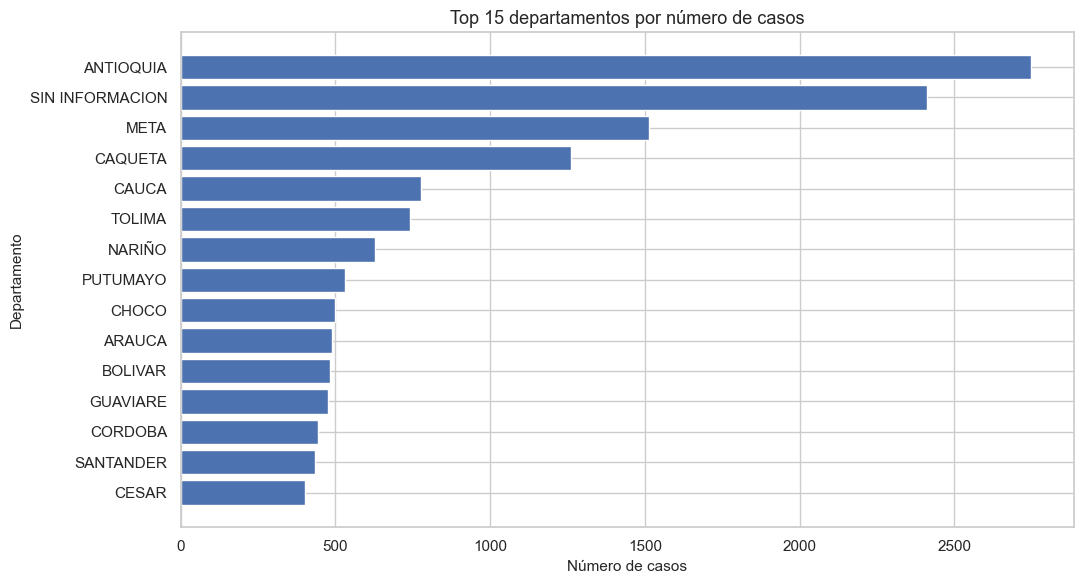

In [22]:
# Figura 1: Top departamentos por número de casos
if "departamento" in df.columns:
    top_departamentos = df["departamento"].value_counts().head(15).sort_values()

    plt.figure(figsize=(11, 6))
    plt.barh(top_departamentos.index.astype(str), top_departamentos.values)
    plt.title("Top 15 departamentos por número de casos")
    plt.xlabel("Número de casos")
    plt.ylabel("Departamento")
    plt.tight_layout()
    plt.savefig(REPORTS_FIGURES / "top_departamentos.png", dpi=300, bbox_inches="tight")
    plt.show()

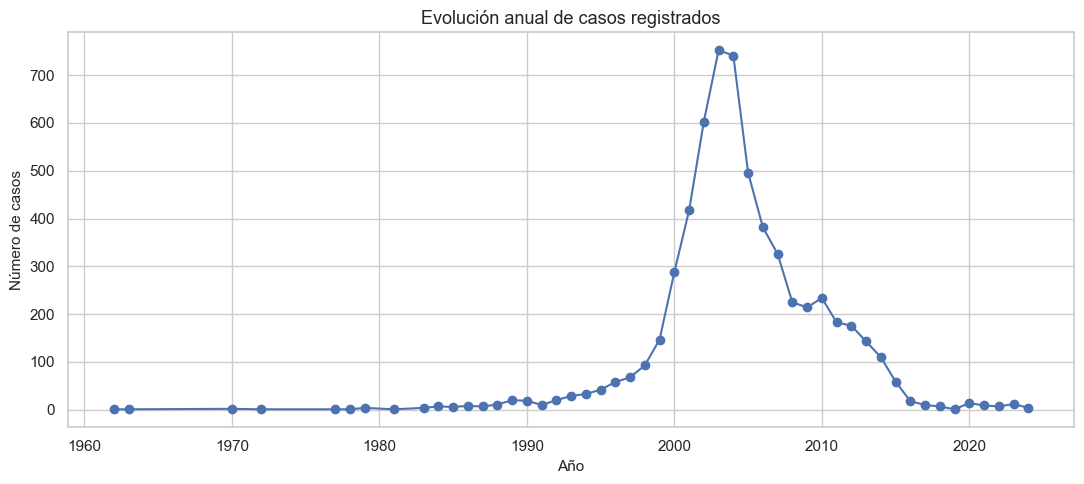

In [23]:
# Figura 2: Evolución anual de casos
if "tabla_anio" in globals() and len(tabla_anio) > 0:
    plt.figure(figsize=(11, 5))
    plt.plot(tabla_anio["anio"], tabla_anio["casos"], marker="o")
    plt.title("Evolución anual de casos registrados")
    plt.xlabel("Año")
    plt.ylabel("Número de casos")
    plt.tight_layout()
    plt.savefig(REPORTS_FIGURES / "casos_por_anio.png", dpi=300, bbox_inches="tight")
    plt.show()

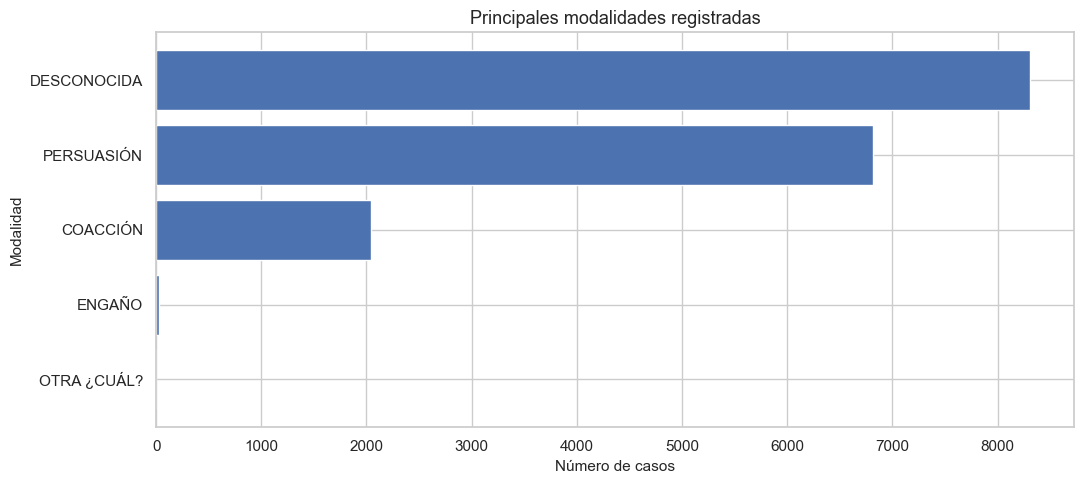

In [24]:
# Figura 3: Modalidad
if "modalidad" in df.columns:
    modalidad_counts = df["modalidad"].value_counts().head(10).sort_values()

    plt.figure(figsize=(11, 5))
    plt.barh(modalidad_counts.index.astype(str), modalidad_counts.values)
    plt.title("Principales modalidades registradas")
    plt.xlabel("Número de casos")
    plt.ylabel("Modalidad")
    plt.tight_layout()
    plt.savefig(REPORTS_FIGURES / "modalidad_casos.png", dpi=300, bbox_inches="tight")
    plt.show()

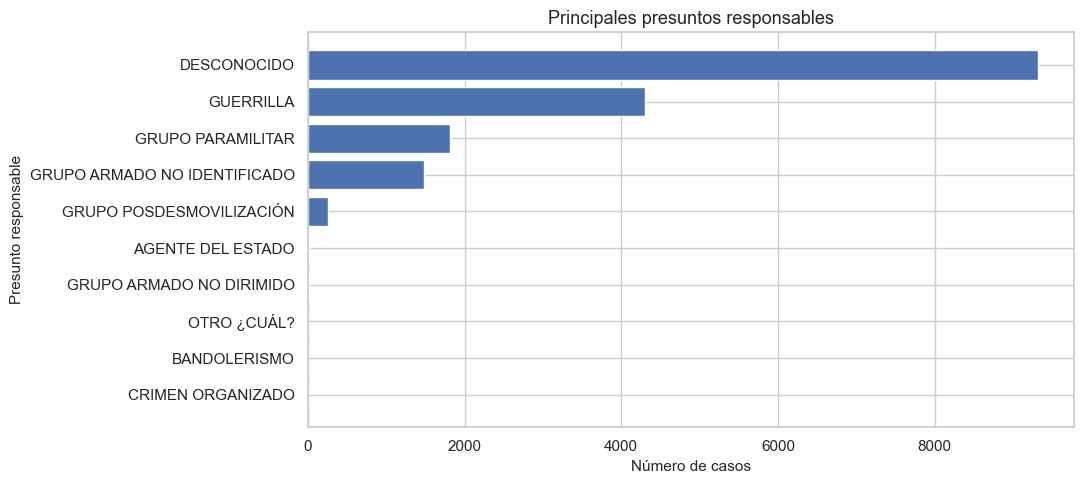

In [25]:
# Figura 4: Presunto responsable
if "presunto_responsable" in df.columns:
    responsable_counts = df["presunto_responsable"].value_counts().head(10).sort_values()

    plt.figure(figsize=(11, 5))
    plt.barh(responsable_counts.index.astype(str), responsable_counts.values)
    plt.title("Principales presuntos responsables")
    plt.xlabel("Número de casos")
    plt.ylabel("Presunto responsable")
    plt.tight_layout()
    plt.savefig(REPORTS_FIGURES / "presunto_responsable.png", dpi=300, bbox_inches="tight")
    plt.show()

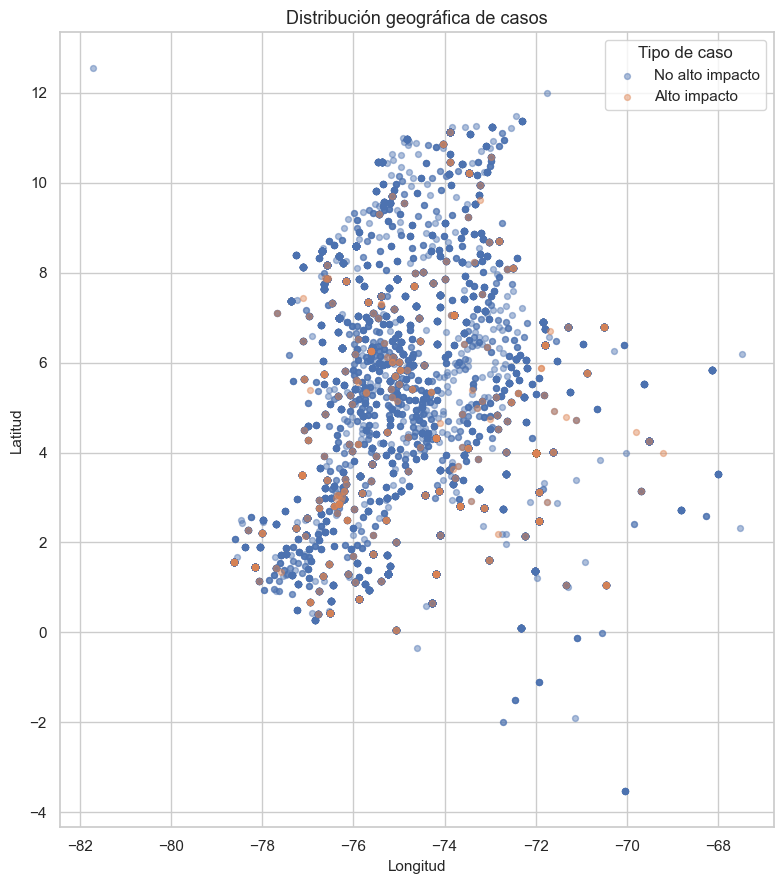

In [26]:
# Figura 5: Distribución geográfica simple con latitud/longitud
geo_df = df.dropna(subset=["latitud", "longitud"]).copy()

if len(geo_df) > 0:
    plt.figure(figsize=(8, 9))
    for clase, grupo in geo_df.groupby("alto_impacto"):
        etiqueta = "Alto impacto" if clase == 1 else "No alto impacto"
        plt.scatter(grupo["longitud"], grupo["latitud"], alpha=0.45, s=18, label=etiqueta)
    plt.title("Distribución geográfica de casos")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.legend(title="Tipo de caso")
    plt.tight_layout()
    plt.savefig(REPORTS_FIGURES / "distribucion_geografica.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No hay coordenadas disponibles para graficar.")

## 8. Modelo predictivo inicial

Pregunta técnica del modelo:

> ¿Qué características territoriales, temporales y del hecho permiten clasificar si un caso tiene alto impacto, definido como más de una víctima registrada?

Este modelo no busca reemplazar análisis experto; sirve como aproximación exploratoria para priorización analítica.

In [27]:
# Selección de variables disponibles para el modelo
variables_categoricas_posibles = [
    "departamento", "region", "modalidad", "presunto_responsable",
    "forma_de_vinculacion", "tipo_de_vinculacion"
]

variables_numericas_posibles = [
    "anio", "mes", "dia", "latitud", "longitud",
    "numero_hechos_simultaneos_binarios",
    "tiene_hecho_simultaneo",
    "tiene_otro_hecho_simultaneo",
    "tiene_violencia_basada_genero"
]

variables_categoricas = [col for col in variables_categoricas_posibles if col in df.columns]
variables_numericas = [col for col in variables_numericas_posibles if col in df.columns]

features = variables_categoricas + variables_numericas

data_modelo = df[features + ["alto_impacto"]].copy()

# Imputación simple para que el modelo no falle
for col in variables_categoricas:
    data_modelo[col] = data_modelo[col].astype("string").fillna("SIN INFORMACION")

for col in variables_numericas:
    data_modelo[col] = pd.to_numeric(data_modelo[col], errors="coerce")
    data_modelo[col] = data_modelo[col].fillna(data_modelo[col].median())

X = data_modelo[features]
y = data_modelo["alto_impacto"]

print("Variables categóricas:", variables_categoricas)
print("Variables numéricas:", variables_numericas)
print("Distribución de la variable objetivo:")
print(y.value_counts(normalize=True).round(4))

Variables categóricas: ['departamento', 'region', 'modalidad', 'presunto_responsable', 'forma_de_vinculacion', 'tipo_de_vinculacion']
Variables numéricas: ['anio', 'mes', 'dia', 'latitud', 'longitud', 'numero_hechos_simultaneos_binarios', 'tiene_hecho_simultaneo', 'tiene_otro_hecho_simultaneo', 'tiene_violencia_basada_genero']
Distribución de la variable objetivo:
alto_impacto
0    0.9771
1    0.0229
Name: proportion, dtype: float64


In [28]:
# Separación entrenamiento/prueba con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), variables_categoricas),
        ("num", "passthrough", variables_numericas)
    ]
)

# Modelo base interpretable
modelo = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred, digits=3, zero_division=0))

              precision    recall  f1-score   support

           0      0.999     0.961     0.980      4202
           1      0.365     0.939     0.525        99

    accuracy                          0.961      4301
   macro avg      0.682     0.950     0.753      4301
weighted avg      0.984     0.961     0.969      4301



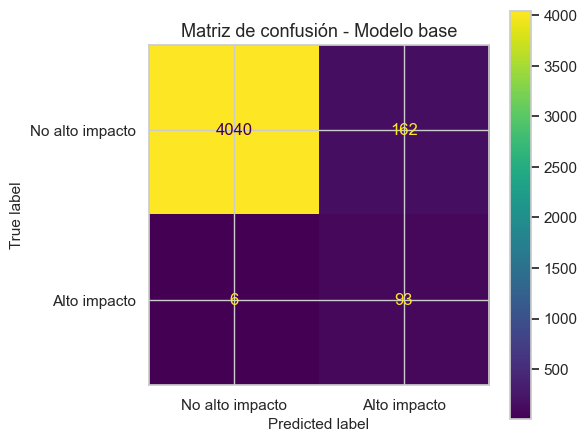

In [29]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No alto impacto", "Alto impacto"])
disp.plot(ax=ax, values_format="d")
plt.title("Matriz de confusión - Modelo base")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "matriz_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Exportación de base limpia

Se exporta la base limpia para anexos, validación y reproducibilidad.

In [30]:
output_csv = DATA_PROCESSED / "sievcac_limpio.csv"
df.to_csv(output_csv, index=False, encoding="utf-8-sig")

print("Base limpia exportada en:", output_csv)
print("Figuras exportadas en:", REPORTS_FIGURES)
print("Tablas exportadas en:", REPORTS_TABLES)

Base limpia exportada en: c:\Users\HOME\Documents\Enfasis Big Data Tools\Proyecto\proyectofinalbdtools_starter\data\processed\sievcac_limpio.csv
Figuras exportadas en: c:\Users\HOME\Documents\Enfasis Big Data Tools\Proyecto\proyectofinalbdtools_starter\reports\figures
Tablas exportadas en: c:\Users\HOME\Documents\Enfasis Big Data Tools\Proyecto\proyectofinalbdtools_starter\reports\tables


## 10. Conclusiones técnicas preliminares

- La base permite analizar patrones temporales, territoriales y de modalidad asociados al reclutamiento y utilización de niños, niñas y adolescentes.
- El procesamiento corrigió el campo de año, normalizó textos y extrajo coordenadas desde el campo geográfico.
- Se construyó una variable objetivo de **alto impacto** basada en casos con más de una víctima registrada.
- El modelo predictivo es una línea base; su principal valor está en mostrar una metodología reproducible para priorización analítica.
- Las figuras y tablas generadas quedan listas para integrarse en el reporte final.

### Siguiente mejora posible

Si queda tiempo, se puede agregar una sección adicional de Big Data Tools usando una de estas opciones:

1. guardar la base limpia en formato parquet;
2. crear un script `.py` con el pipeline;
3. documentar cómo se escalaría a Docker, PostgreSQL/PostGIS o MongoDB.